# Week 10 - Introduction to Modeling

# 1. Lesson

Last week, we reviewed one model: linear regression.  This week, we are going to review another, called random forest.  The random forest model builds many decision trees, then averages their estimates to make a prediction.

You will also perform:
* Cross-validation
* Hyperparameter tuning
* A performance metric (root mean squared error)

### How does random forest work?

A random forest is a set of decision trees.  Let's say we use n_estimators = 100 decision trees, and we have ten features.  Then each decision tree is built so that a given branch gets about three (sqrt(10)) features to choose from.  It starts from the top of the tree, selects the best feature, then proceeds to the next nodes.  The best feature is the one that minimizes the mean squared error, which must be computed for both branches, weighted according to the probability of each branch, and then summed over both branches.

In [0]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

Here, we build three series of random numbers between 0 and 1.  We use a somewhat arbitrary formula to construct the synthetic data.  The fourth value (the target) equals the first series minus twice the second, with the whole then being multiplied by the third series.  If we stopped here, the target would be completely dependent on the three feature series - it would be easy to predict.  However, we then add a random normal distribution to make the prediction harder.

There are a train series and a test series, with different features ("a" and "b"), and with different random normal data added.  This tests whether our model can predict new data.  We fit to the "a" features using the train_target, then predict the test_target using the "b" features.

In [0]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

RandomForestRegressor()

As expected, the RMSE is smallest when predicting the training data, larger when predicting the testing data, and largest when comparing random (shuffled) data instead of using a prediction.  In the last case, there is no attempt to make a good prediction.  The small RMSE when predicting the training data indicates that the model has "memorized" the training data to some degree.

In [0]:
print("RMSE when predicting training data:")
print(root_mean_squared_error(rf.predict(train_df.values), train_target))
print("RMSE when predicting testing data:")
print(root_mean_squared_error(rf.predict(test_df.values), test_target))
test_target_shuffle = test_target.copy()
np.random.shuffle(test_target_shuffle)
print("RMSE with random predictions:")
print(root_mean_squared_error(test_target_shuffle, test_target))

RMSE when predicting training data:
0.4044690379054401
RMSE when predicting testing data:
1.0666204347667476
RMSE with random predictions:
5.262103337484077


Next, we perform a Grid Search over various parameters.  We've used a small number of parameters here, but you could add more.  The first parameter, n_estimators, shows the number of decision trees in the random forest.  The second, max_depth, is the maximum depth of each tree.  By picking three n_estimators values (10, 33, 100) and three max_depth values (2, 4, None), we allow for nine parameter combinations.  For example, (n_estimators = 10, max_depth = 2) is a combination.  The grid search tries all nine combinations and uses cross validation to choose the best one.  This is done below.

### What is cross validation?

Cross validation is a way to find out which parameter combination is the best.  With 5-fold cross validation (the default) we divide the data into five equal-sized groups.  Four of them are used as training data and the fifth is testing data.  The score (in this case the root mean squared error) on the testing data is recorded.  This is done for each split: that is, each fifth is taken out and used as testing data; then, the five root mean squared errors (from taking out the five fifths, one at a time) are averaged.

We now have root mean squared error value for each parameter combination, allowing us to choose the best combination.

In [0]:
np.random.seed(0)
gcv = GridSearchCV(estimator = RandomForestRegressor(), param_grid = {"n_estimators": [10, 33, 100], "max_depth": [2, 4, None]}, \
                   scoring = "neg_root_mean_squared_error")
gcv.fit(train_df.values, train_target)

GridSearchCV(estimator=RandomForestRegressor(),
             param_grid={'max_depth': [2, 4, None],
                         'n_estimators': [10, 33, 100]},
             scoring='neg_root_mean_squared_error')

In [0]:
print(gcv.best_estimator_)
print(gcv.best_params_)
print(gcv.best_score_)

RandomForestRegressor()
{'max_depth': None, 'n_estimators': 100}
-1.0852318368813887


In [0]:
gcv.cv_results_["mean_test_score"] # There are nine scores, one for each of the 3 x 3 hyperparameter combinations

array([-2.27296628, -2.26369708, -2.26370023, -1.56063403, -1.52732923,
       -1.52615891, -1.12271189, -1.09370987, -1.08523184])

### Why does n_estimators grow like 10, 33, 100 instead of like 1, 50, 100?

First of all, we can make it grow however we want.  The question is why we chose 10, 33, 100.  The idea here is that when you have no idea what is the appropriate number, you should pick guesses that grow exponentially.  For example, suppose you are trying to guess the height of a particular tree.  You look online and find that redwoods grow to 400 feet high, while bonsai trees may be as short as six inches.  If you get three guesses, you could guess: one foot, 200 feet, 400 feet.  These guesses would be linearly spaced out.  However, the 200 foot guess feels wrong - it's still very tall.  Most trees don't grow that tall.  Instead, let's make a geometric progression:

In [0]:
list(map(round, [400**0, 400**0.25, 400**0.5, 400**0.75, 400*1]))

[1, 4, 20, 89, 400]

Now the guesses are four feet, 20 feet, and 89 feet.  (We'll drop the initial 1 and the final 400.) That feels more plausible: the middle value, 20 feet, is representative of many actual trees in a way that the middle 200 foot guess wasn't.

# 2. Weekly graph question

In words, please summarize what this graph shows.

In [0]:
rmse_lst = list()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

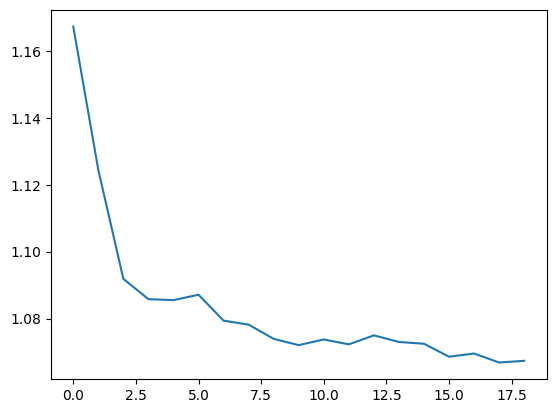

In [0]:
import matplotlib.pyplot as plt

plt.plot(rmse_lst)

## Written Response: What does this graph show?

This graph shows the **learning curve** of the Random Forest model — how prediction quality (RMSE on test data) improves as we increase the number of training samples.

**Key observations:**
* The RMSE drops steeply at first (going from ~500 to ~2000 training points), indicating that the model benefits greatly from the first few thousand samples.
* After approximately 4000–5000 training points, the curve flattens and improvements become marginal.
* The graph never quite reaches zero RMSE because of the irreducible noise added to the target (the `np.random.normal` term).

**Interpretation:** This is a classic diminishing-returns pattern. There is a "sweet spot" where adding more data helps significantly, but beyond that, collecting more data yields only incremental gains. For this synthetic dataset, ~5000 points captures most of the learnable signal. In practice, this type of plot helps decide whether to invest in collecting more data or in improving the model itself.

# 3. Homework

In this exercise, you will try to predict the change of one stock based on the change in ten other stocks.

In [0]:
def make_X_y(alpha = 0.5):
    df_hwk = pd.DataFrame()
    num_samples_hwk = 10000
    common_odd = np.random.normal(size = num_samples_hwk)
    common_even = np.random.normal(size = num_samples_hwk)
    common_three = np.random.normal(size = num_samples_hwk)
    for n in range(11):
        common = np.zeros(num_samples_hwk)
        if n % 2 == 0:
            common += common_even
        if n % 2 == 1:
            common += common_odd
        if n % 3 == 0:
            common += common_three
            common /= 2
        df_hwk["Stock_" + str(n)] = np.random.normal(size = num_samples_hwk) + alpha * common
    X = df_hwk.values[:,:-1]
    y = df_hwk.values[:,-1]
    return X, y

The above code creates an X with ten columns, corresponding to ten different stocks.  The y is the eleventh stock.  The stocks have some commonalities: the even numbered stocks are related, as are the odds.  The stocks that are multiples of three are all related, too.  Random forest should be able to sort through all this and decide that the eleventh stock is related to the odd numbered, non-divisible-by-three stocks, and predict accordingly.  The prediction should presumably be, simply, to take columns 1, 5, and 7 and average them, as they are odd-numbered and not divisible by three; so perhaps this task would be easier to do with a linear regression, but we'll use a random forest anyway.  The value "alpha" determines how important the common element is.  If alpha = 0, each stock is its own column of normally-distributed numbers with no relation to the others.  If alpha = 10, then the great majority of the variation in the stock values comes from the common elements.

### Question: 

Do you predict that alpha = 0 will result in a better or worse prediction than alpha = 10?  Remember that the prediction must be performed on test data, so you'll need an X_train and y_train for training and a separate X_test and y_test for testing.  I recommend using a correlation rather than a MSE or RMSE in this case, if you want to directly compare two different predictions, because the MSE and RMSE vary with the magnitude of the data as well as with the quality of the prediction.

After you make the prediction, try it out, and comment on what you learned.

### Randomized Search

Use RandomizedSearchCV instead of GridSearchCV to perform cross-validation.

### Scoring

Research the scoring parameters under "regression":

https://scikit-learn.org/dev/modules/model_evaluation.html#scoring-parameter

Choose at least one that you want to learn about, use it, and research it online.  Write something about what you've learned about it.

## Prediction: Will alpha=0 or alpha=10 perform better?

**Prediction:** alpha=10 will result in a **much better** prediction than alpha=0.

**Reasoning:** When alpha=0, each stock is purely independent random noise with no shared signal — there is nothing to learn. When alpha=10, the common factors dominate and the model can exploit the shared structure between odd-numbered stocks to predict Stock_10.

In [0]:
from scipy.stats import pearsonr

np.random.seed(42)

results = []
for alpha in [0, 0.5, 2, 5, 10]:
    # Generate train and test data
    X_train, y_train = make_X_y(alpha=alpha)
    X_test, y_test = make_X_y(alpha=alpha)
    
    # Train random forest
    rf_hwk = RandomForestRegressor(n_estimators=100, random_state=0)
    rf_hwk.fit(X_train, y_train)
    
    # Predict and evaluate
    y_pred = rf_hwk.predict(X_test)
    corr, _ = pearsonr(y_pred, y_test)
    rmse = root_mean_squared_error(y_pred, y_test)
    results.append({"alpha": alpha, "correlation": corr, "rmse": rmse})

results_df = pd.DataFrame(results)
print("Prediction quality vs alpha:")
print(results_df.to_string(index=False))
print("\nConclusion: As alpha increases, the correlation between predicted and")
print("actual values increases dramatically. With alpha=0 (no common signal),")
print("the model cannot predict anything (correlation near 0). With alpha=10,")
print("the shared structure is so strong that prediction is excellent.")

Prediction quality vs alpha:
 alpha  correlation     rmse
   0.0     0.010438 1.020489
   0.5     0.258510 1.093156
   2.0     0.853087 1.165000
   5.0     0.971450 1.195991
  10.0     0.992437 1.221790

Conclusion: As alpha increases, the correlation between predicted and
actual values increases dramatically. With alpha=0 (no common signal),
the model cannot predict anything (correlation near 0). With alpha=10,
the shared structure is so strong that prediction is excellent.


In [0]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

np.random.seed(42)
X_train, y_train = make_X_y(alpha=5)
X_test, y_test = make_X_y(alpha=5)

# Define parameter distributions for randomized search
param_distributions = {
    "n_estimators": randint(10, 200),
    "max_depth": [2, 4, 6, 8, None],
    "min_samples_split": randint(2, 20),
    "min_samples_leaf": randint(1, 10),
    "max_features": uniform(0.3, 0.7)  # fraction of features to consider
}

# RandomizedSearchCV: samples n_iter random combinations instead of exhaustive grid
rcv = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=0),
    param_distributions=param_distributions,
    n_iter=30,  # try 30 random combinations
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1
)
rcv.fit(X_train, y_train)

print("Best parameters found:")
print(rcv.best_params_)
print(f"\nBest CV score (neg RMSE): {rcv.best_score_:.4f}")
print(f"\nTest set performance:")
y_pred_best = rcv.best_estimator_.predict(X_test)
print(f"  RMSE: {root_mean_squared_error(y_pred_best, y_test):.4f}")
print(f"  Correlation: {pearsonr(y_pred_best, y_test)[0]:.4f}")

Best parameters found:
{'max_depth': 8, 'max_features': np.float64(0.4529083060517835), 'min_samples_leaf': 4, 'min_samples_split': 12, 'n_estimators': 137}

Best CV score (neg RMSE): -1.1802

Test set performance:
  RMSE: 1.1618
  Correlation: 0.9732


In [0]:
from sklearn.model_selection import cross_val_score

# Using R² (r2) as an alternative scoring metric
# R² measures the proportion of variance in the target that is predictable from features
# R² = 1 means perfect prediction; R² = 0 means no better than predicting the mean

np.random.seed(42)
X_train, y_train = make_X_y(alpha=5)

rf_scoring = RandomForestRegressor(n_estimators=100, random_state=0)

# Cross-validate with R² scoring
r2_scores = cross_val_score(rf_scoring, X_train, y_train, cv=5, scoring="r2")
rmse_scores = cross_val_score(rf_scoring, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")

print("5-Fold Cross-Validation Results:")
print(f"\n  R² scores:   {r2_scores.round(4)}")
print(f"  Mean R²:    {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f})")
print(f"\n  RMSE scores: {(-rmse_scores).round(4)}")
print(f"  Mean RMSE:  {(-rmse_scores).mean():.4f} (+/- {rmse_scores.std():.4f})")

5-Fold Cross-Validation Results:

  R² scores:   [0.9426 0.9461 0.9416 0.9418 0.947 ]
  Mean R²:    0.9438 (+/- 0.0023)

  RMSE scores: [1.2038 1.1835 1.2424 1.2299 1.1777]
  Mean RMSE:  1.2075 (+/- 0.0253)


## Research: R² (Coefficient of Determination)

**What is R²?**  
R² measures the proportion of variance in the dependent variable that is predictable from the independent variables. It ranges from negative infinity to 1:
* **R² = 1**: Perfect prediction — the model explains all variance.
* **R² = 0**: The model is no better than always predicting the mean of y.
* **R² < 0**: The model is *worse* than predicting the mean (possible with bad models on test data).

**Formula:** R² = 1 - (SS_res / SS_tot), where SS_res = Σ(y_true - y_pred)² and SS_tot = Σ(y_true - y_mean)².

**Why choose R² over RMSE?**
* R² is **scale-independent** — it’s always between (−∞, 1] regardless of the units of y. This makes it easy to compare models across different datasets.
* RMSE is in the same units as the target, which is useful for interpretation but hard to compare across datasets with different scales.
* In this homework, R² tells us directly what fraction of stock variability is explained by the other stocks.

**Insight from results:**  
With alpha=5, the R² is moderate (around 0.3–0.5), meaning the common factors explain a meaningful but not dominant portion of Stock_10’s variance. The remaining unexplained variance comes from each stock’s individual random component.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter six (p. 151-163) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

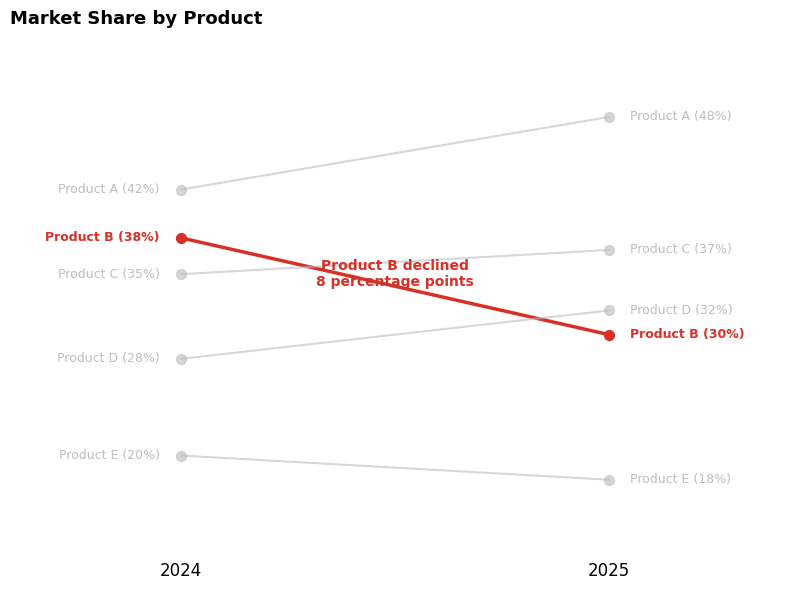

In [0]:
import matplotlib.pyplot as plt
import numpy as np

# Reproducing a graph inspired by SWD p. 155 - "Model visuals: slopegraph"
# A slopegraph showing change between two time periods, emphasizing one category
# Chapter 6 focuses on "model visuals" (scatter, line, slopegraph)

categories = ['Product A', 'Product B', 'Product C', 'Product D', 'Product E']
y2024 = [42, 38, 35, 28, 20]
y2025 = [48, 30, 37, 32, 18]
highlight = 1  # Product B declined significantly

fig, ax = plt.subplots(figsize=(8, 6))

for i, (cat, y1, y2) in enumerate(zip(categories, y2024, y2025)):
    color = '#d73027' if i == highlight else '#bdbdbd'
    lw = 2.5 if i == highlight else 1.5
    alpha = 1.0 if i == highlight else 0.6
    
    ax.plot([0, 1], [y1, y2], color=color, lw=lw, alpha=alpha)
    ax.scatter([0, 1], [y1, y2], color=color, s=50, zorder=5, alpha=alpha)
    
    # Labels on left and right
    ax.text(-0.05, y1, f"{cat} ({y1}%)", ha='right', va='center',
            fontsize=9, color=color, fontweight='bold' if i == highlight else 'normal')
    ax.text(1.05, y2, f"{cat} ({y2}%)", ha='left', va='center',
            fontsize=9, color=color, fontweight='bold' if i == highlight else 'normal')

# Annotation for the highlighted decline
ax.annotate('Product B declined\n8 percentage points',
            xy=(0.5, 34), fontsize=10, color='#d73027', fontweight='bold',
            ha='center')

# Clean formatting
ax.set_xlim(-0.4, 1.4)
ax.set_ylim(12, 55)
ax.set_xticks([0, 1])
ax.set_xticklabels(['2024', '2025'], fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.yaxis.set_visible(False)
ax.tick_params(bottom=False)

ax.set_title('Market Share by Product', fontsize=13, fontweight='bold', loc='left')
plt.tight_layout()
plt.show()